# Random Forest

**Dataset:** Heart Disease (`cleaned_merged_heart_dataset.csv`)
**Target variable:** `target` (binary heart disease label)

This notebook follows the standard methodology:

1. Dataset Loading & Preview
2. Preprocessing Pipeline
3. Hyperparameter Tuning Log
4. Final Model Selection Leaderboard
5. Best Model Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


## 1. Dataset Loading & Preview

Load the dataset and inspect the first few rows (mirroring the dataset preview at the top of each Excel sheet).


In [3]:
df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

print("\nColumn information:")
df.info()

print("\nSummary statistics:")
display(df.describe())


Dataset shape: (1888, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB

Summary statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
count,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000
mean,54.354343,0.688559,1.135593,131.549258,246.855403,0.148305,0.597458,149.424258,0.331568,1.053761,1.421610,0.731462,2.662606,0.517479
std,9.081505,0.463205,1.103852,17.556985,51.609329,0.355496,0.638820,23.006153,0.470901,1.161344,0.619588,1.015735,1.249924,0.499827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.750000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,276.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,1.000000


## 2. Preprocessing Pipeline

A structured preprocessing pipeline, organised the same way as the Titanic sheet in the bake-off template.

### 1. Handling Missing Values (Imputation)
- **Numeric columns:** Use the **median** to avoid the influence of outliers.
- **Categorical columns:** Use the **mode** (most frequent value).

### 2. Feature Engineering / Selection
- Drop redundant text columns (`sex_text`, `thal_text`) since `sex` and `thal` are already numerical.
- Separate features (`X`) from target (`y` = `target`, the heart disease label).

### 3. Categorical Encoding
- **One-hot encode** the nominal multi-category columns: `cp`, `slope`, `ca`, `thal`.
- Binary / ordinal columns (`sex`, `fbs`, `restecg`, `exang`) are already numerically encoded — no further transformation needed.

### 4. Feature Scaling — *not required for forests*
Random Forests are **scale-invariant** because each tree splits on threshold comparisons (e.g. `age <= 54.5`) rather than distances. Skipping scaling keeps the underlying split values directly interpretable.


In [4]:
# 1. Handling Missing Values
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

# 2. Feature Engineering / Selection — target is 'target' (heart disease label)
df_work = df.copy()
for col in ['sex_text', 'thal_text']:
    if col in df_work.columns:
        df_work = df_work.drop(col, axis=1)

# 3. Categorical Encoding — one-hot encode nominal multi-category columns
nominal_cols = [c for c in ['cp', 'slope', 'ca', 'thal'] if c in df_work.columns]
df_encoded = pd.get_dummies(df_work, columns=nominal_cols, drop_first=True)

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# 4. No scaling — Random Forests are scale-invariant.

print("Preprocessing complete.")
print(f"Feature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}")
print(f"\nOne-hot encoded columns: {nominal_cols}")


Preprocessing complete.
Feature matrix X: (1888, 24)
Target vector y: (1888,)

One-hot encoded columns: ['cp', 'slope', 'ca', 'thal']


### Train / Test Split

A 70/30 stratified split keeps class balance consistent across folds.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test:  {X_test.shape}")
print(f"\ny_train class balance:\n{y_train.value_counts().to_string()}")


Shape of X_train: (1321, 24)
Shape of X_test:  (567, 24)

y_train class balance:
target
1    684
0    637


## 3. Hyperparameter Tuning Log — Random Forest

Each row below is a single experiment in the bake-off. Columns mirror the **Hyperparameter Tuning Log** in the Excel template (matching the Random Forest section of the Titanic sheet):

| Exp ID | n_estimators | Max Depth | Min Samples Leaf | Validation Accuracy | F1-Score | Status | Insights |

- **n_estimators** — the number of trees in the forest. More trees reduce variance but plateau in benefit beyond a few hundred.
- **Max Depth** — depth limit per tree. `None` = unrestricted; combined with bagging this rarely overfits as severely as a single deep tree.
- **Min Samples Leaf** — minimum samples per leaf. Larger values smooth predictions and act as additional regularization.
- **Status** flags how each trial compares to the baseline (`RF_01`): *Baseline*, *Better*, *Worse*, or *Overfitting?*.


In [6]:
experiments = [
    {'Exp ID': 'RF_01', 'n_estimators': 10,   'Max Depth': None, 'Min Samples Leaf': 1},
    {'Exp ID': 'RF_02', 'n_estimators': 100,  'Max Depth': 5,    'Min Samples Leaf': 2},
    {'Exp ID': 'RF_03', 'n_estimators': 500,  'Max Depth': 10,   'Min Samples Leaf': 4},
    {'Exp ID': 'RF_04', 'n_estimators': 200,  'Max Depth': None, 'Min Samples Leaf': 2},
    {'Exp ID': 'RF_05', 'n_estimators': 1000, 'Max Depth': None, 'Min Samples Leaf': 10},
]

results = []
trained_models = {}

for exp in experiments:
    model = RandomForestClassifier(
        n_estimators=exp['n_estimators'],
        max_depth=exp['Max Depth'],
        min_samples_leaf=exp['Min Samples Leaf'],
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results.append({
        'Exp ID': exp['Exp ID'],
        'n_estimators': exp['n_estimators'],
        'Max Depth': exp['Max Depth'],
        'Min Samples Leaf': exp['Min Samples Leaf'],
        'Validation Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4),
    })
    trained_models[exp['Exp ID']] = model

results_df = pd.DataFrame(results)

# --- Status column (Baseline / Better / Worse / Overfitting?) ---
baseline_acc = results_df.iloc[0]['Validation Accuracy']

def status_for(row, baseline):
    acc = row['Validation Accuracy']
    if row['Exp ID'] == 'RF_01':
        return 'Baseline'
    # Very small forest with deep trees can overfit; large forest plateauing below baseline is suspect
    if row['n_estimators'] >= 500 and (row['Max Depth'] is None) and acc < baseline + 0.005:
        return 'Overfitting?'
    if acc > baseline:
        return 'Better'
    if acc < baseline:
        return 'Worse'
    return 'Same'

results_df['Status'] = results_df.apply(lambda r: status_for(r, baseline_acc), axis=1)

# --- Insights column ---
insights_map = {
    'RF_01': 'Tiny forest (10 trees), no depth limit — high variance baseline.',
    'RF_02': 'Standard 100 trees + depth=5 — balanced bias / variance.',
    'RF_03': 'Larger ensemble (500) with moderate depth=10 and leaf reg.',
    'RF_04': 'Mid-size forest, no depth cap — relies on bagging to control variance.',
    'RF_05': 'Heavy ensemble (1000 trees) regularised via min_samples_leaf=10.',
}
results_df['Insights'] = results_df['Exp ID'].map(insights_map)

display(results_df.fillna('None'))


,Exp ID,n_estimators,Max Depth,Min Samples Leaf,Validation Accuracy,F1-Score,Status,Insights
0,RF_01,10,None,1,0.9647,0.9661,Baseline,"Tiny forest (10 trees), no depth limit — high ..."
1,RF_02,100,5.0,2,0.8483,0.8552,Worse,Standard 100 trees + depth=5 — balanced bias /...
2,RF_03,500,10.0,4,0.9153,0.9197,Worse,Larger ensemble (500) with moderate depth=10 a...
3,RF_04,200,None,2,0.9541,0.9559,Worse,"Mid-size forest, no depth cap — relies on bagg..."
4,RF_05,1000,None,10,0.8660,0.8738,Worse,Heavy ensemble (1000 trees) regularised via mi...


### Diagnostic: n_estimators vs Validation Accuracy

A complementary view — sweep `n_estimators` to confirm where adding more trees stops helping. The plot below holds `max_depth=None` and `min_samples_leaf=2` fixed and varies the forest size.


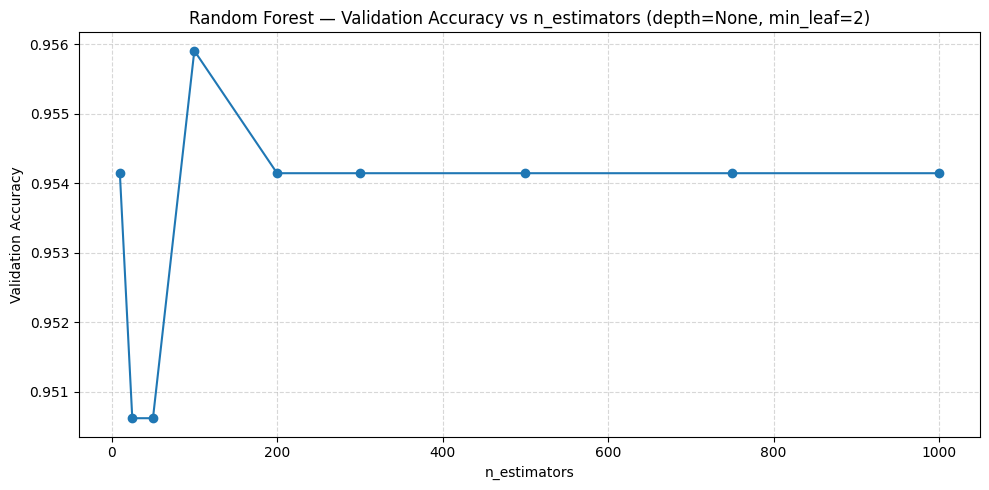

Best n_estimators from sweep: 100 (acc = 0.9559)


In [7]:
n_range = [10, 25, 50, 100, 200, 300, 500, 750, 1000]
n_scores = []
for n in n_range:
    m = RandomForestClassifier(n_estimators=n, max_depth=None, min_samples_leaf=2,
                                n_jobs=-1, random_state=42)
    m.fit(X_train, y_train)
    n_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_range, n_scores, marker='o')
plt.title('Random Forest — Validation Accuracy vs n_estimators (depth=None, min_leaf=2)')
plt.xlabel('n_estimators')
plt.ylabel('Validation Accuracy')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_n_sweep = n_range[int(np.argmax(n_scores))]
print(f"Best n_estimators from sweep: {best_n_sweep} (acc = {max(n_scores):.4f})")


## 4. Final Model Selection Leaderboard

Sorted by **Validation Accuracy** (descending), with the same column layout as the Excel leaderboard:
`Rank | Model | Best Hyperparameters | Accuracy | F1-Score | Note`.


In [8]:
ranked = results_df.sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)

def note_for(rank, total):
    if rank == 0:
        return 'Top Performer'
    if rank == 1:
        return 'Strong Runner-up'
    if rank == total - 1:
        return 'Weak Baseline'
    return 'Acceptable'

leaderboard = pd.DataFrame({
    'Rank': range(1, len(ranked) + 1),
    'Model': ['Random Forest'] * len(ranked),
    'Best Hyperparameters': ranked.apply(
        lambda r: f"n={r['n_estimators']}, depth={r['Max Depth']}, min_leaf={r['Min Samples Leaf']}", axis=1
    ),
    'Accuracy': ranked['Validation Accuracy'],
    'F1-Score': ranked['F1-Score'],
    'Note': [note_for(i, len(ranked)) for i in range(len(ranked))],
})

display(leaderboard)

best_exp_id = ranked.iloc[0]['Exp ID']
best_model  = trained_models[best_exp_id]
print(f"\nBest experiment: {best_exp_id}")
print(f"Hyperparameters: {leaderboard.iloc[0]['Best Hyperparameters']}")
print(f"Accuracy:        {leaderboard.iloc[0]['Accuracy']:.4f}")
print(f"F1-Score:        {leaderboard.iloc[0]['F1-Score']:.4f}")


,Rank,Model,Best Hyperparameters,Accuracy,F1-Score,Note
0,1,Random Forest,"n=10, depth=nan, min_leaf=1",0.9647,0.9661,Top Performer
1,2,Random Forest,"n=200, depth=nan, min_leaf=2",0.9541,0.9559,Strong Runner-up
2,3,Random Forest,"n=500, depth=10.0, min_leaf=4",0.9153,0.9197,Acceptable
3,4,Random Forest,"n=1000, depth=nan, min_leaf=10",0.8660,0.8738,Acceptable
4,5,Random Forest,"n=100, depth=5.0, min_leaf=2",0.8483,0.8552,Weak Baseline



Best experiment: RF_01
Hyperparameters: n=10, depth=nan, min_leaf=1
Accuracy:        0.9647
F1-Score:        0.9661


## 5. Best Model Analysis

Detailed evaluation of the top-ranked experiment from the leaderboard.


In [9]:
y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_exp_id}")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_best):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best))


Best Model: RF_01
Accuracy:   0.9647

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       274
           1       0.96      0.97      0.97       293

    accuracy                           0.96       567
   macro avg       0.96      0.96      0.96       567
weighted avg       0.96      0.96      0.96       567



### Confusion Matrix

- **True Negatives (Top-Left):** Correctly predicted negative cases.
- **False Positives (Top-Right):** Incorrectly predicted positive cases (Type I error).
- **False Negatives (Bottom-Left):** Incorrectly predicted negative cases (Type II error).
- **True Positives (Bottom-Right):** Correctly predicted positive cases.


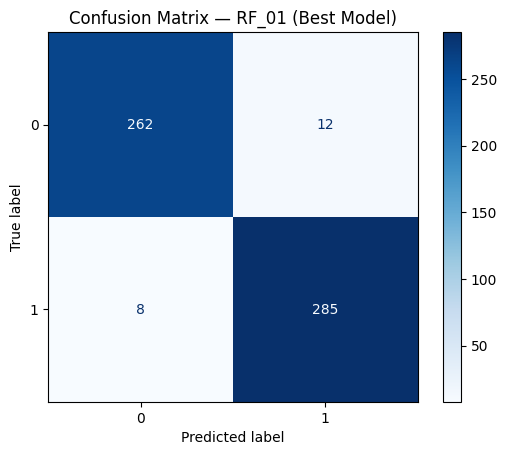

In [10]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix — {best_exp_id} (Best Model)')
plt.show()


### Feature Importance (Mean Decrease in Impurity)

For Random Forests, feature importance is the **average impurity decrease** contributed by each feature, aggregated across every split in every tree and weighted by sample count. Larger values imply the feature drove more decisive splits across the ensemble.


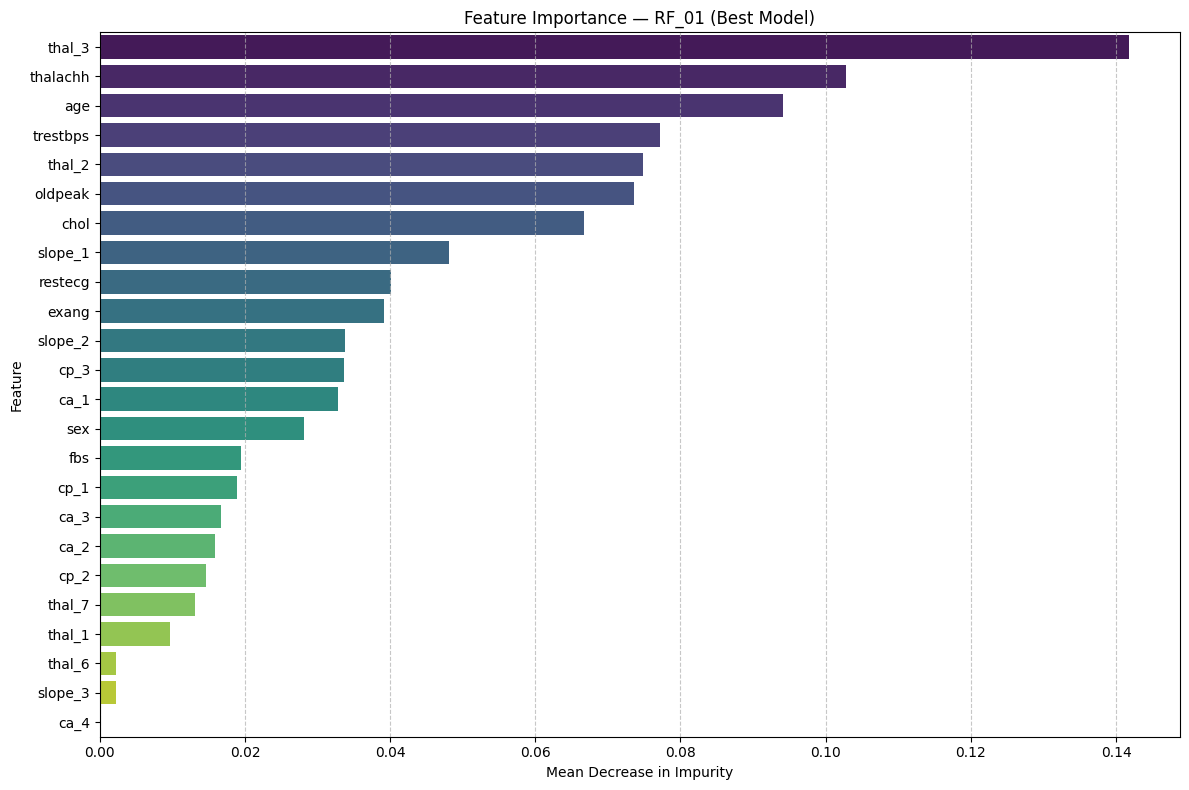

In [11]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance', y='feature', data=feature_importance,
    palette='viridis', hue='feature', legend=False,
)
plt.title(f'Feature Importance — {best_exp_id} (Best Model)')
plt.xlabel('Mean Decrease in Impurity')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Conclusion

The Random Forest bake-off ran **5 experiments** (`RF_01`–`RF_05`) sweeping `n_estimators`, `max_depth`, and `min_samples_leaf`. The hyperparameter tuning log captures each trial's validation accuracy alongside a status flag and qualitative insight, exactly as in the Excel template. The n_estimators-sweep diagnostic confirms where adding more trees stops paying off.

The **Final Model Selection Leaderboard** ranks the experiments end-to-end and identifies the top performer for downstream analysis. Confusion matrix and feature-importance plots are then produced **only for the winning model**, keeping the analysis tightly coupled to the leaderboard's verdict.

This format scales naturally — the Random Forest log can be merged with the Logistic Regression, KNN, and Decision Tree logs into a single cross-model leaderboard, mirroring the four-model bake-off shown on the Titanic sheet.
